

# 🎬 Chapter 1 — CNN: Teaching Milo to See Images

## 🎭 Characters

👩 **Riya**
👨‍🏫 **Professor Arjun**
🤖 **Milo**

---

# 🌅 Scene: The New Problem

Riya brings two images to class.

* one image of a **cat**
* one image of a **dog**

She asks:

> **Sir, linear regression, logistic regression, trees, KNN — all were fine for normal tables. But how do we teach Milo to understand images?**

Professor Arjun smiles.

> **That is exactly why CNN came.**

Milo writes on the board:

```text
CNN = Convolutional Neural Network
```

---

# 🧠 First, what problem are we solving?

With normal ML, data often looks like this:

| Hours Studied | Marks |
| ------------- | ----- |
| 2             | 40    |
| 5             | 80    |

But image data looks different.

A picture is not just one value.
It is made of **many tiny pixels**.

For example:

* a small grayscale image might be `28 x 28`
* that means **784 pixel values**
* a color image has even more values

So image data is huge.

---


# 😄 Intuition

Professor Arjun says:

> **Using normal ML directly on images is like asking someone to identify a face by reading a giant Excel sheet of pixel numbers.**
>
> Possible? Maybe.
> Smart? Not really.

That is why CNN is used.

---

# 🧠 Why CNN came

CNN came because images have **patterns** like:

* edges
* corners
* curves
* eyes
* ears
* shapes

A CNN is good at finding these patterns.

So instead of looking at the whole image in one big scary chunk, CNN looks at it **piece by piece**.

---

# 🧠 Core idea of CNN

Professor Arjun explains:

> **CNN does not look at the whole image at once.**
> It scans small parts of the image and learns useful patterns.

Milo writes:

```text
CNN learns:
small patterns → bigger patterns → full object
```

Example:

```text
edge → eye → face → cat
```

That is the whole magic.

---




# 📦 Main parts of CNN

A basic CNN usually has:

1. **Convolution layer**
2. **Activation function (ReLU)**
3. **Pooling layer**
4. **Flatten**
5. **Dense layer**
6. **Output layer**



# 🧪 Step 1 — Import libraries


In [1]:
# Import tensorflow because we will build the CNN using keras inside tensorflow
import tensorflow as tf

# Import keras layers that help us build CNN step by step
from tensorflow.keras import layers, models

# Import matplotlib to show images
import matplotlib.pyplot as plt



# 🧠 Code explanation

### `import tensorflow as tf`

This imports TensorFlow, which is a deep learning library.

### `from tensorflow.keras import layers, models`

This imports ready-made CNN building blocks.

### `import matplotlib.pyplot as plt`

This helps us display images.



# 🧪 Step 2 — Load the dataset


In [2]:

# Load MNIST dataset
# x_train, y_train = training images and labels
# x_test, y_test = testing images and labels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

---

# 🧠 What this gives us

* `x_train` = training images
* `y_train` = correct answers for training images
* `x_test` = test images
* `y_test` = correct answers for test images

Example:

* image of handwritten `5`
* label = `5`

---



# 🧪 Step 3 — Check the shape of data



In [3]:
# Print shape of training data
print("x_train shape:", x_train.shape)

# Print shape of test data
print("x_test shape:", x_test.shape)

x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)


You will usually see something like:

```python
x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)
```

Meaning:

* `60000` training images
* each image is `28 x 28`
* `10000` test images

---



# 🧪 Step 4 — Display one image



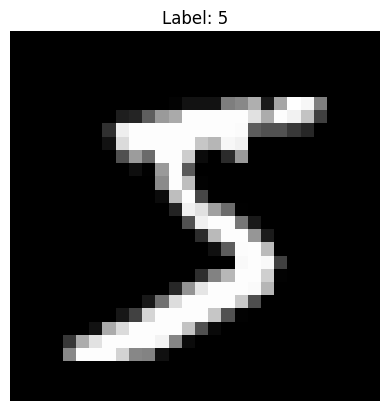

In [4]:
# Show the first training image
plt.imshow(x_train[0], cmap="gray")

# Show title using its correct label
plt.title(f"Label: {y_train[0]}")

# Remove axis values for cleaner image
plt.axis("off")

# Display the image
plt.show()



# 🧠 Code explanation

### `x_train[0]`

This means the first image.

### `cmap="gray"`

Since MNIST is grayscale, we show it in black-and-white.

### `y_train[0]`

This is the correct digit for that image.

---

# 🧪 Step 5 — Normalize pixel values


In [5]:

# Convert pixel values from 0-255 to 0-1
x_train = x_train / 255.0
x_test = x_test / 255.0




---

# 🧠 Why do we do this?

Original pixel values are usually between:

```text
0 to 255
```

Where:

* `0` = black
* `255` = white

We divide by `255` to make values smaller:

```text
0 to 1
```

This helps the model learn better.

---



# 🧪 Step 6 — Reshape images for CNN



In [6]:
# Add one extra dimension because CNN expects image data in this format:
# (number_of_images, height, width, channels)
# MNIST is grayscale, so channels = 1
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))



---

# 🧠 Very simple explanation

Right now an image looks like:

```text
28 x 28
```

But CNN expects:

```text
28 x 28 x 1
```

That extra `1` means:

```text
1 color channel
```

Because MNIST is grayscale.

For RGB color images, channels would be `3`.

---

# 🧪 Step 7 — Build the CNN model


In [7]:
# Create a sequential model
# Sequential means layers will be added one after another in order
model = models.Sequential()

# First convolution layer
# 32 filters means the model will learn 32 small pattern detectors
# (3,3) means each filter looks at a 3x3 part of the image at a time
# activation="relu" helps the network learn non-linear patterns
# input_shape tells the model the size of each image
model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))

# Pooling layer
# This reduces the image size and keeps important information
model.add(layers.MaxPooling2D((2, 2)))

# Second convolution layer
# Now the model learns more advanced patterns
model.add(layers.Conv2D(64, (3, 3), activation="relu"))

# Second pooling layer
model.add(layers.MaxPooling2D((2, 2)))

# Flatten layer
# This converts 2D feature maps into 1D so dense layers can use them
model.add(layers.Flatten())

# Dense hidden layer
# 64 neurons learn from the extracted image features
model.add(layers.Dense(64, activation="relu"))

# Output layer
# 10 neurons because digits are from 0 to 9
# softmax gives probability for each class
model.add(layers.Dense(10, activation="softmax"))

C:\Users\Edunet Foundation\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)




---

# 🧠 Super simple layer meaning

## 1) Convolution layer

This looks for tiny patterns like:

* edges
* curves
* small shapes

## 2) Pooling layer

This shrinks the information so the model keeps important things and removes extra detail.

## 3) Flatten

This turns image features into one long list.

## 4) Dense layer

This learns from those features.

## 5) Output layer

This tells which digit is most likely.

---


# 🧪 Step 8 — See model summary


In [8]:
# Show the structure of the CNN model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

```

This prints:

* layer names
* output shapes
* number of parameters

# 🧪 Step 9 — Compile the model


In [9]:

# Compile the model
# optimizer="adam" helps the model learn efficiently
# loss="sparse_categorical_crossentropy" is used for multi-class classification
# metrics=["accuracy"] tells us to track accuracy during training
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])


---

# 🧠 Code explanation

### Optimizer

This helps the model improve its mistakes.

### Loss

This measures how wrong the model is.

### Accuracy

This tells how many predictions are correct.

---

# 🧪 Step 10 — Train the model


In [10]:
# Train the CNN model
# epochs=5 means the model will see the full training data 5 times
# validation_data checks performance on unseen test data during training
history = model.fit(x_train, y_train,
                    epochs=5,
                    validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9563 - loss: 0.1461 - val_accuracy: 0.9828 - val_loss: 0.0504
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9855 - loss: 0.0465 - val_accuracy: 0.9862 - val_loss: 0.0439
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9897 - loss: 0.0322 - val_accuracy: 0.9889 - val_loss: 0.0342
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9922 - loss: 0.0247 - val_accuracy: 0.9874 - val_loss: 0.0402
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9945 - loss: 0.0177 - val_accuracy: 0.9872 - val_loss: 0.0439







# 🧠 Very simple explanation

Training means:

* show image
* model predicts digit
* compare with correct answer
* adjust weights
* repeat many times

That is how learning happens.

---



# 🧪 Step 11 — Evaluate the model


In [11]:

# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)

# Print final test accuracy
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9872 - loss: 0.0439
Test Accuracy: 0.9872000217437744


# 🧪 Step 12 — Predict one image


In [12]:
# Predict probabilities for the first test image
prediction = model.predict(x_test[:1])

# Print probabilities
print("Prediction probabilities:", prediction)

# Get the class with highest probability
predicted_label = prediction.argmax()

# Print predicted digit
print("Predicted digit:", predicted_label)

# Print actual digit
print("Actual digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Prediction probabilities: [[8.4506895e-11 4.0261557e-07 6.2181916e-06 2.5188786e-04 1.2708716e-08
  4.5023432e-07 1.3322000e-12 9.9973971e-01 7.4310702e-07 4.8627652e-07]]
Predicted digit: 7
Actual digit: 7


# 🧠 What this is doing

The model does not directly say:

```text
It is 7
```

First it gives probabilities like:

```text
0 -> 0.01
1 -> 0.00
2 -> 0.02
...
7 -> 0.93
```

Then we choose the biggest probability.

That becomes the final answer.

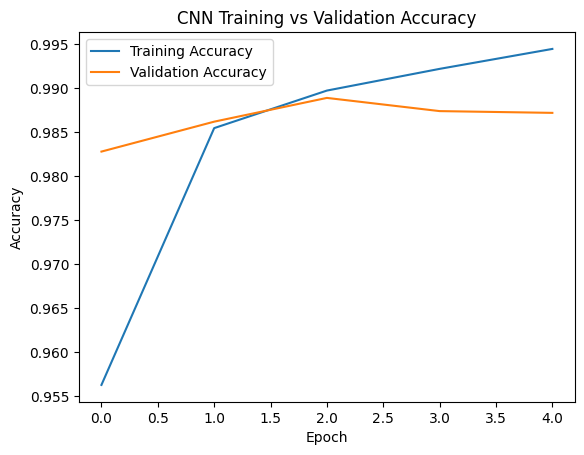

In [13]:
# Plot training accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")

# Plot validation accuracy
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

# Add labels
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Add title
plt.title("CNN Training vs Validation Accuracy")

# Show legend
plt.legend()

# Show graph
plt.show()

---

# 🧠 What We will observe

As epochs increase:

* training accuracy usually goes up
* validation accuracy also goes up if model is learning well

This is nice because students can literally **see learning happening**.



---

# 🧪 Practice


```python
# Show image number 10
plt.imshow(x_train[10].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[10]}")
plt.axis("off")
plt.show()
```

```python
# Predict image number 10
prediction = model.predict(x_train[10:11])
print("Predicted:", prediction.argmax())
print("Actual:", y_train[10])
```

```python
# Change epochs from 5 to 3 or 10 and observe accuracy
```

---

